In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score

In [2]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

# Set Matplotlib defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs


def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def score_dataset(X, y, model=XGBRegressor()):
    # Label encoding for categoricals
    for colname in X.select_dtypes(["category", "object"]):
        X[colname], _ = X[colname].factorize()
    # Metric for Housing competition is RMSLE (Root Mean Squared Log Error)
    score = cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_squared_log_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score

In [3]:
rain_file_path = 'data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)
X_test = test_data

In [4]:
display(rain_data)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [5]:
features = rain_data.columns
print("Correlation with SalePrice:\n")
print(rain_data[features].corrwith(rain_data.rainfall))

Correlation with SalePrice:

id               0.033674
day             -0.000462
pressure        -0.049886
maxtemp         -0.079304
temparature     -0.049660
mintemp         -0.026841
dewpoint         0.081965
humidity         0.454213
cloud            0.641191
sunshine        -0.555287
winddirection   -0.006939
windspeed        0.111625
rainfall         1.000000
dtype: float64


In [6]:
#cols = X.columns požito v 1.verzy
cols = ["humidity", "cloud", "sunshine", "windspeed"]
cols_for_scaling = rain_data.loc[:, ["humidity", "cloud", "sunshine", "windspeed"]]
cols_for_scaling

,humidity,cloud,sunshine,windspeed
0,87.0,88.0,1.1,17.2
1,95.0,91.0,0.0,21.9
2,75.0,47.0,8.3,18.1
3,95.0,95.0,0.0,35.6
4,52.0,45.0,3.6,24.8
...,...,...,...,...
2185,97.0,88.0,0.1,22.1
2186,91.0,88.0,0.0,35.3
2187,79.0,79.0,5.0,32.9
2188,92.0,93.0,0.1,18.0


In [7]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()
df_scaled = ms.fit_transform(cols_for_scaling)
#print(scaled_X)
df_scaled = pd.DataFrame(df_scaled, columns=[cols])
display(df_scaled)

,humidity,cloud,sunshine,windspeed
0,0.813559,0.877551,0.090909,0.232305
1,0.949153,0.908163,0.000000,0.317604
2,0.610169,0.459184,0.685950,0.248639
3,0.949153,0.948980,0.000000,0.566243
4,0.220339,0.438776,0.297521,0.370236
...,...,...,...,...
2185,0.983051,0.877551,0.008264,0.321234
2186,0.881356,0.877551,0.000000,0.560799
2187,0.677966,0.785714,0.413223,0.517241
2188,0.898305,0.928571,0.008264,0.246824


In [8]:
X = rain_data.copy()
y = X.pop("rainfall")
#X = X.loc[:, features]

# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(df_scaled)
print(loadings)

                PC1       PC2       PC3       PC4
humidity  -0.502147 -0.297999 -0.809311  0.063719
cloud     -0.595554 -0.085117  0.344104 -0.720876
sunshine   0.591032 -0.002119 -0.420148 -0.688587
windspeed -0.209389  0.950761 -0.223794 -0.046099


In [9]:
mutual_info_regression(X_pca, y)

array([0.21658459, 0.00859997, 0.01716772, 0.04991335])

In [10]:
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X, y)
score = cross_val_score(rf_model, X, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.84664989 0.89845356 0.91179446 0.87236831 0.85882131]


0.8776175077070999

In [11]:
X["PC1"] = X_pca["PC1"]

In [12]:
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X, y)
score = cross_val_score(rf_model, X, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.86806144 0.89669557 0.91112005 0.86680516 0.86161724]


0.8808598920979863

In [13]:
X["PC3"] = X_pca["PC3"]

In [14]:
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X, y)
score = cross_val_score(rf_model, X, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.86407574 0.90402551 0.91524435 0.87179666 0.8608947 ]


0.883207389820857

In [15]:
X["PC4"] = X_pca["PC4"]

In [16]:
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X, y)
score = cross_val_score(rf_model, X, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.87399364 0.90509818 0.91266342 0.86910571 0.86461737]


0.885095663809814

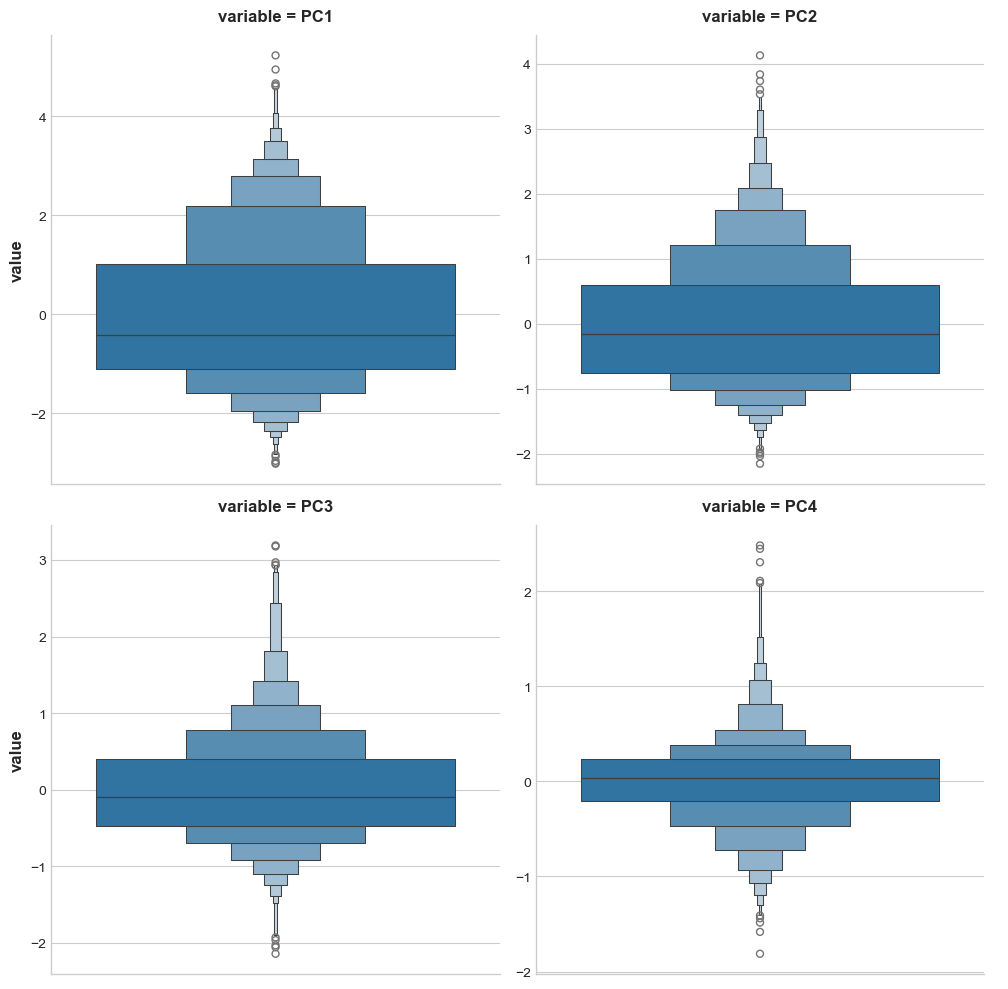

In [17]:
sns.catplot(
    y="value",
    col="variable",
    data=X_pca.melt(),
    kind='boxen',
    sharey=False,
    col_wrap=2,
);

In [18]:
component = "PC2"
cols_all = rain_data.columns
idx = X_pca[component].sort_values(ascending=False).index
rain_data.loc[idx, cols_all]
#df.loc[idx, ["SalePrice", "Neighborhood", "SaleCondition"] + features]

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
735,735,6,1021.6,14.3,13.7,11.8,11.1,67.0,91.0,0.0,20.0,59.5,0
1472,1472,13,1023.9,18.2,17.2,15.4,13.7,69.0,55.0,2.4,60.0,55.5,0
749,749,20,1021.6,20.3,16.1,14.3,13.2,76.0,19.0,10.2,10.0,55.5,0
1463,1463,4,1020.0,21.1,18.4,16.6,14.0,75.0,56.0,3.3,60.0,55.5,0
368,368,4,1022.9,16.2,13.3,11.6,12.1,84.0,80.0,0.4,20.0,59.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1898,1898,74,1015.9,23.3,21.1,20.5,17.3,96.0,88.0,0.1,80.0,7.9,1
1544,1544,85,1011.2,24.7,21.4,20.1,20.6,92.0,83.0,0.4,120.0,5.5,1
47,47,48,1016.5,21.6,19.2,17.5,19.0,95.0,92.0,0.3,40.0,6.9,1
792,792,63,1018.4,21.3,19.1,17.2,18.9,98.0,100.0,0.0,50.0,8.1,1


In [19]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, 
                                                                train_size=0.8, test_size=0.2,
                                                                random_state=0)

In [20]:
cross_valid_scores = {}

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

In [25]:
%%time
parameters = {
    "n_estimators": [5, 10, 15, 20, 25], 
    "max_depth": [3, 5, 7, 9, 11, 13],
}

model_random_forest = RandomForestClassifier(
    random_state=1,
    class_weight='balanced',
)

model_random_forest = GridSearchCV(
    model_random_forest, 
    parameters, 
    cv=5,
    scoring='accuracy',
)

model_random_forest.fit(X_train, y_train)

print('-----')
print(f'Best parameters {model_random_forest.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: '+ \
    f'{model_random_forest.best_score_:.3f}'
)
cross_valid_scores['random_forest'] = model_random_forest.best_score_
print('-----')

parameters = {
    "max_depth": [3, 5, 7, 9, 11, 13],
}

model_desicion_tree = DecisionTreeClassifier(
    random_state=1,
    class_weight='balanced',
)

model_desicion_tree = GridSearchCV(
    model_desicion_tree, 
    parameters, 
    cv=5,
    scoring='accuracy',
)

model_desicion_tree.fit(X_train, y_train)

print('-----')
print(f'Best parameters {model_desicion_tree.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + \
    f'{model_desicion_tree.best_score_:.3f}'
)
cross_valid_scores['desicion_tree'] = model_desicion_tree.best_score_
print('-----')

-----
Best parameters {'max_depth': 9, 'n_estimators': 25}
Mean cross-validated accuracy score of the best_estimator: 0.868
-----
-----
Best parameters {'max_depth': 5}
Mean cross-validated accuracy score of the best_estimator: 0.822
-----
CPU times: user 7.5 s, sys: 117 ms, total: 7.62 s
Wall time: 8.46 s
